# 🔢 Métodos Matemáticos

`Matemática/Ciências` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Álgebra linear, EDOs, Fourier, Laplace e ferramentas numéricas.**

Ferramentas matemáticas usadas em engenharia: sistemas lineares, autovalores, equações diferenciais e séries de Fourier com NumPy e SymPy.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


Metodos_Matematicos.pdf
Páginas: 1


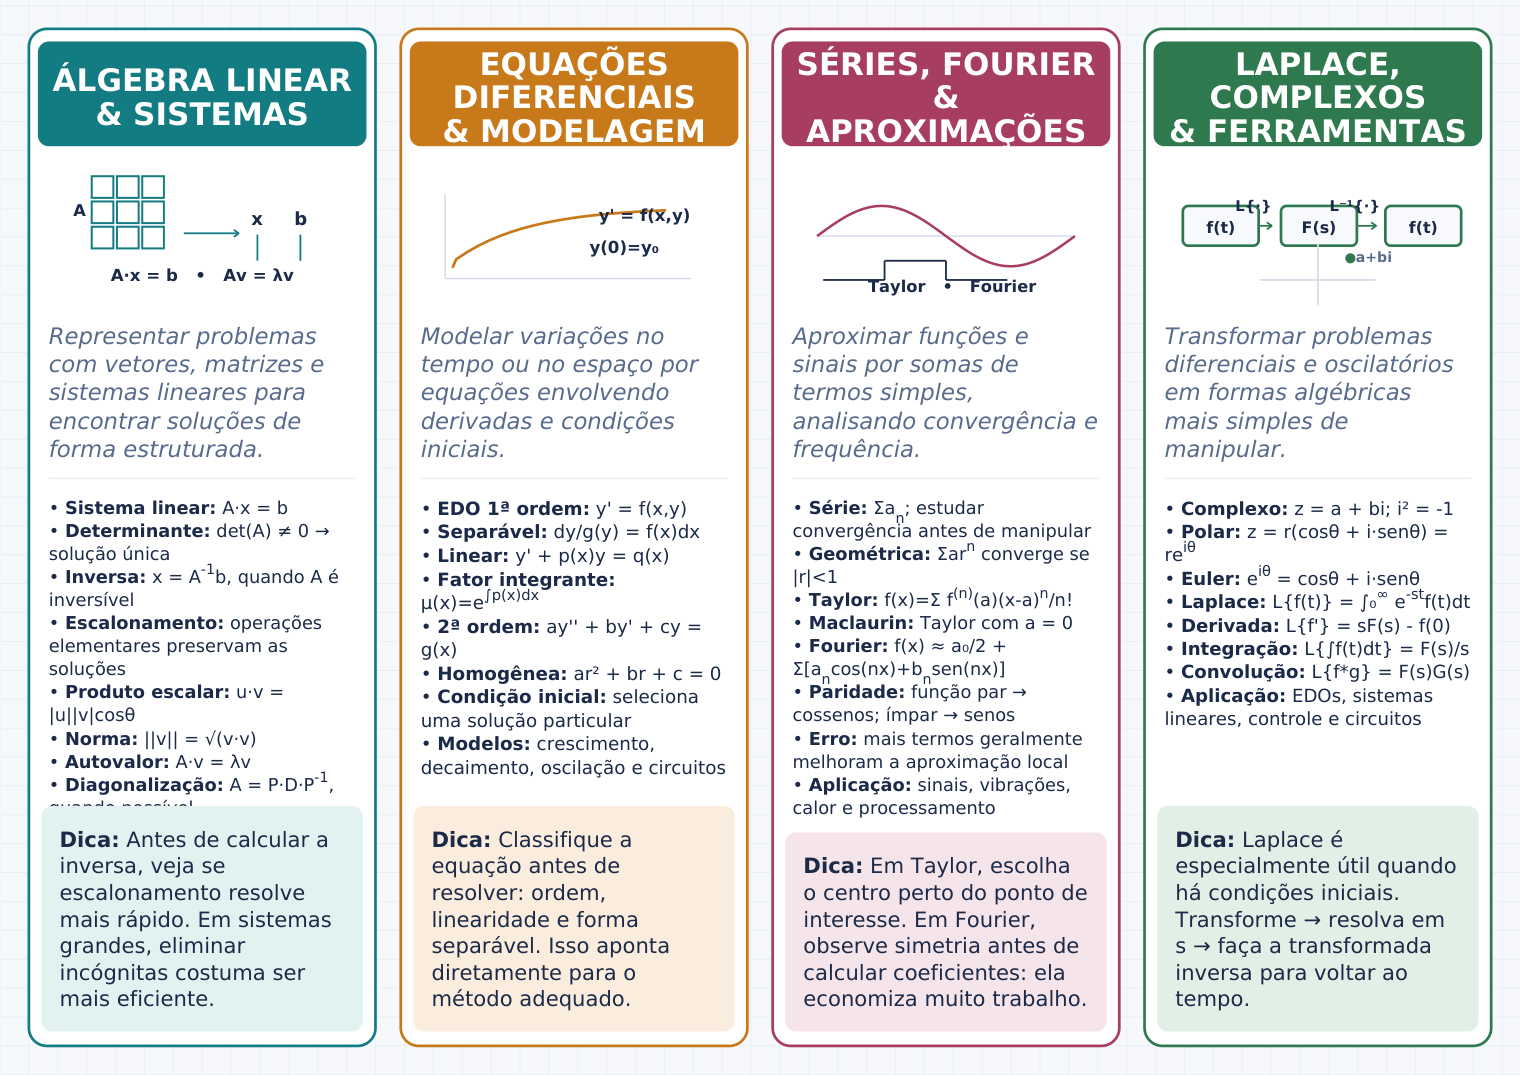

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path
from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Metodos_Matematicos.pdf')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR/'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR/'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR/'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond', normal='DVCond', bold='DVCond-Bold', italic='DVCond-Oblique', boldItalic='DVCond-Bold')

BG=HexColor('#F6F8FB'); GRID=HexColor('#E6EBF3'); INK=HexColor('#1C2B4A'); MUTED=HexColor('#5A6B8C'); WHITE=HexColor('#FFFFFF'); LINE=HexColor('#E7ECF4'); AXIS=HexColor('#D7DEEA')
TEAL,TEAL_T=HexColor('#147D82'),HexColor('#E3F2F1')
AMBER,AMBER_T=HexColor('#C97A1A'),HexColor('#FBEDDD')
BERRY,BERRY_T=HexColor('#A83E63'),HexColor('#F6E4EB')
GREEN,GREEN_T=HexColor('#2F7A4F'),HexColor('#E2F0E7')

CARDS=[
    {'title':'ÁLGEBRA LINEAR<br/>&amp; SISTEMAS','color':TEAL,'tint':TEAL_T,'kind':'algebra','idea':'Representar problemas com vetores, matrizes e sistemas lineares para encontrar soluções de forma estruturada.','formulas':[
        '<b>Sistema linear:</b> A·x = b',
        '<b>Determinante:</b> det(A) ≠ 0 → solução única',
        '<b>Inversa:</b> x = A<super>-1</super>b, quando A é inversível',
        '<b>Escalonamento:</b> operações elementares preservam as soluções',
        '<b>Produto escalar:</b> u·v = |u||v|cosθ',
        '<b>Norma:</b> ||v|| = √(v·v)',
        '<b>Autovalor:</b> A·v = λv',
        '<b>Diagonalização:</b> A = P·D·P<super>-1</super>, quando possível',
    ],'tip':'Antes de calcular a inversa, veja se escalonamento resolve mais rápido. Em sistemas grandes, eliminar incógnitas costuma ser mais eficiente.'},

    {'title':'EQUAÇÕES DIFERENCIAIS<br/>&amp; MODELAGEM','color':AMBER,'tint':AMBER_T,'kind':'edo','idea':'Modelar variações no tempo ou no espaço por equações envolvendo derivadas e condições iniciais.','formulas':[
        '<b>EDO 1ª ordem:</b> y\' = f(x,y)',
        '<b>Separável:</b> dy/g(y) = f(x)dx',
        '<b>Linear:</b> y\' + p(x)y = q(x)',
        '<b>Fator integrante:</b> μ(x)=e<super>∫p(x)dx</super>',
        '<b>2ª ordem:</b> ay\'\' + by\' + cy = g(x)',
        '<b>Homogênea:</b> ar² + br + c = 0',
        '<b>Condição inicial:</b> seleciona uma solução particular',
        '<b>Modelos:</b> crescimento, decaimento, oscilação e circuitos',
    ],'tip':'Classifique a equação antes de resolver: ordem, linearidade e forma separável. Isso aponta diretamente para o método adequado.'},

    {'title':'SÉRIES, FOURIER<br/>&amp; APROXIMAÇÕES','color':BERRY,'tint':BERRY_T,'kind':'series','idea':'Aproximar funções e sinais por somas de termos simples, analisando convergência e frequência.','formulas':[
        '<b>Série:</b> Σa<sub>n</sub>; estudar convergência antes de manipular',
        '<b>Geométrica:</b> Σar<super>n</super> converge se |r|&lt;1',
        '<b>Taylor:</b> f(x)=Σ f<super>(n)</super>(a)(x-a)<super>n</super>/n!',
        '<b>Maclaurin:</b> Taylor com a = 0',
        '<b>Fourier:</b> f(x) ≈ a₀/2 + Σ[a<sub>n</sub>cos(nx)+b<sub>n</sub>sen(nx)]',
        '<b>Paridade:</b> função par → cossenos; ímpar → senos',
        '<b>Erro:</b> mais termos geralmente melhoram a aproximação local',
        '<b>Aplicação:</b> sinais, vibrações, calor e processamento',
    ],'tip':'Em Taylor, escolha o centro perto do ponto de interesse. Em Fourier, observe simetria antes de calcular coeficientes: ela economiza muito trabalho.'},

    {'title':'LAPLACE, COMPLEXOS<br/>&amp; FERRAMENTAS','color':GREEN,'tint':GREEN_T,'kind':'laplace','idea':'Transformar problemas diferenciais e oscilatórios em formas algébricas mais simples de manipular.','formulas':[
        '<b>Complexo:</b> z = a + bi; i² = -1',
        '<b>Polar:</b> z = r(cosθ + i·senθ) = re<super>iθ</super>',
        '<b>Euler:</b> e<super>iθ</super> = cosθ + i·senθ',
        '<b>Laplace:</b> L{f(t)} = ∫₀<super>∞</super> e<super>-st</super>f(t)dt',
        '<b>Derivada:</b> L{f\'} = sF(s) - f(0)',
        '<b>Integração:</b> L{∫f(t)dt} = F(s)/s',
        '<b>Convolução:</b> L{f*g} = F(s)G(s)',
        '<b>Aplicação:</b> EDOs, sistemas lineares, controle e circuitos',
    ],'tip':'Laplace é especialmente útil quando há condições iniciais. Transforme → resolva em s → faça a transformada inversa para voltar ao tempo.'},
]

CARD_TOP=PAGE_H-16; CARD_BOTTOM=16; CARD_H=CARD_TOP-CARD_BOTTOM; GAP=14; CARD_W=(PAGE_W-2*MARGIN-3*GAP)/4
STYLE_TITLE=ParagraphStyle('title',fontName='DVCond-Bold',fontSize=17.2,leading=18.6,textColor=WHITE,alignment=1)
STYLE_IDEA=ParagraphStyle('idea',fontName='DVCond-Oblique',fontSize=12.6,leading=15.6,textColor=MUTED)
STYLE_TIP=ParagraphStyle('tip',fontName='DVCond',fontSize=11.7,leading=14.7,textColor=INK)

def arrow(c,x1,y1,x2,y2,color,width=1.1,head=4):
    c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2)
    a=math.atan2(y2-y1,x2-x1)
    for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(a+d),y2+head*math.sin(a+d))

def diagram_algebra(c,ox,oy,dw,dh,color):
    # Matrix and vector flow
    c.setFillColor(INK); c.setFont('DVCond-Bold',9)
    c.drawString(ox+dw*.08,oy+dh*.64,'A')
    c.setStrokeColor(color); c.setLineWidth(1.1)
    x=ox+dw*.14; y=oy+dh*.40
    for r in range(3):
        for col in range(3):
            c.rect(x+col*14,y+r*14,12,12,stroke=1,fill=0)
    arrow(c,ox+dw*.44,oy+dh*.51,ox+dw*.62,oy+dh*.51,color,1.0,3.5)
    c.setFillColor(INK); c.setFont('DVCond-Bold',10)
    c.drawString(ox+dw*.66,oy+dh*.57,'x')
    c.drawString(ox+dw*.80,oy+dh*.57,'b')
    c.setStrokeColor(color)
    c.line(ox+dw*.68,oy+dh*.31,ox+dw*.68,oy+dh*.50)
    c.line(ox+dw*.82,oy+dh*.31,ox+dw*.82,oy+dh*.50)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2)
    c.drawCentredString(ox+dw*.50,oy+dh*.16,'A·x = b   •   Av = λv')

def diagram_edo(c,ox,oy,dw,dh,color):
    x0=ox+dw*.08; y0=oy+dh*.18
    c.setStrokeColor(AXIS); c.setLineWidth(.8); c.line(x0,y0,x0+dw*.80,y0); c.line(x0,y0,x0,y0+dh*.62)
    p=c.beginPath(); p.moveTo(x0+4,y0+6)
    for i in range(1,21):
        t=i/20; x=x0+dw*.72*t; y=y0+dh*(.08+.44*(1-math.exp(-3*t)))
        p.lineTo(x,y)
    c.setStrokeColor(color); c.setLineWidth(1.5); c.drawPath(p,stroke=1,fill=0)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawString(ox+dw*.58,oy+dh*.60,"y' = f(x,y)")
    c.drawString(ox+dw*.55,oy+dh*.37,"y(0)=y₀")

def diagram_series(c,ox,oy,dw,dh,color):
    x0=ox+dw*.08; y0=oy+dh*.49
    c.setStrokeColor(AXIS); c.setLineWidth(.8); c.line(x0,y0,ox+dw*.92,y0)
    # sine curve
    p=c.beginPath(); p.moveTo(x0,y0)
    for i in range(61):
        t=i/60; x=x0+dw*.84*t; y=y0+dh*.22*math.sin(2*math.pi*t)
        p.lineTo(x,y)
    c.setStrokeColor(color); c.setLineWidth(1.4); c.drawPath(p,stroke=1,fill=0)
    # partial approximation blocks
    c.setStrokeColor(INK); c.setLineWidth(1.0)
    c.line(ox+dw*.10,oy+dh*.17,ox+dw*.30,oy+dh*.17)
    c.line(ox+dw*.30,oy+dh*.17,ox+dw*.30,oy+dh*.31)
    c.line(ox+dw*.30,oy+dh*.31,ox+dw*.50,oy+dh*.31)
    c.line(ox+dw*.50,oy+dh*.31,ox+dw*.50,oy+dh*.17)
    c.line(ox+dw*.50,oy+dh*.17,ox+dw*.70,oy+dh*.17)
    c.setFillColor(INK); c.setFont('DVCond-Bold',9.0); c.drawCentredString(ox+dw*.52,oy+dh*.08,'Taylor   •   Fourier')

def diagram_laplace(c,ox,oy,dw,dh,color):
    # time domain -> s domain -> inverse
    boxes=[(ox+dw*.06,'f(t)'),(ox+dw*.38,'F(s)'),(ox+dw*.72,'f(t)')]
    y=oy+dh*.42
    for x,lab in boxes:
        c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.roundRect(x,y,42,22,3,fill=1,stroke=1)
        c.setFillColor(INK); c.setFont('DVCond-Bold',8.8); c.drawCentredString(x+21,y+7,lab)
    arrow(c,ox+dw*.06+42,y+11,ox+dw*.38-5,y+11,color,1.0,3.5)
    arrow(c,ox+dw*.38+42,y+11,ox+dw*.72-5,y+11,color,1.0,3.5)
    c.setFillColor(INK); c.setFont('DVCond-Bold',8.2); c.drawCentredString(ox+dw*.29,oy+dh*.67,'L{·}')
    c.drawCentredString(ox+dw*.62,oy+dh*.67,'L⁻¹{·}')
    # complex plane
    cx=ox+dw*.50; cy=oy+dh*.17
    c.setStrokeColor(AXIS); c.line(cx-32,cy,cx+32,cy); c.line(cx,cy-14,cx,cy+20)
    c.setFillColor(color); c.circle(cx+18,cy+12,2.8,stroke=0,fill=1)
    c.setFillColor(MUTED); c.setFont('DVCond-Bold',7.8); c.drawString(cx+21,cy+10,'a+bi')

DIAGRAMS={'algebra':diagram_algebra,'edo':diagram_edo,'series':diagram_series,'laplace':diagram_laplace}

def draw_card(c,card,cx):
    color,tint=card['color'],card['tint']
    c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
    header_h=58; header_y=CARD_TOP-7-header_h; c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
    p=Paragraph(card['title'],STYLE_TITLE); _,ph=p.wrapOn(c,CARD_W-22,header_h-6); p.drawOn(c,cx+11,header_y+(header_h-ph)/2)
    cursor=header_y-11; dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
    p=Paragraph(card['idea'],STYLE_IDEA); _,ph=p.wrapOn(c,CARD_W-22,70); p.drawOn(c,cx+11,cursor-ph); cursor-=ph+9
    c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
    tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tip_txt_h=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tip_txt_h+22); tip_top=tip_y+tip_h
    html='<br/>'.join('• '+x for x in card['formulas']); avail=cursor-tip_top-10; fs=10.75; lead=13.65
    while True:
        st=ParagraphStyle('body_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK)
        body=Paragraph(html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
        if bh<=avail or fs<=9.95: break
        fs-=.1; lead-=.1
    body.drawOn(c,cx+11,cursor-bh)
    c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tip_txt_h)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Métodos Matemáticos - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(OUT)


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Metodos_Matematicos.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 ÁLGEBRA LINEAR & SISTEMAS

**Ideia:** Representar problemas com vetores, matrizes e sistemas lineares para encontrar soluções de forma estruturada.

- Sistema linear: A·x = b
- Determinante: det(A) ≠ 0 → solução única
- Inversa: x = A^-1b, quando A é inversível
- Escalonamento: operações elementares preservam as soluções
- Produto escalar: u·v = |u||v|cosθ
- Norma: ||v|| = √(v·v)
- Autovalor: A·v = λv
- Diagonalização: A = P·D·P^-1, quando possível

> 💡 **Dica:** Antes de calcular a inversa, veja se escalonamento resolve mais rápido. Em sistemas grandes, eliminar incógnitas costuma ser mais eficiente.

### 🟢 EQUAÇÕES DIFERENCIAIS & MODELAGEM

**Ideia:** Modelar variações no tempo ou no espaço por equações envolvendo derivadas e condições iniciais.

- EDO 1ª ordem: y' = f(x,y)
- Separável: dy/g(y) = f(x)dx
- Linear: y' + p(x)y = q(x)
- Fator integrante: μ(x)=e^∫p(x)dx
- 2ª ordem: ay'' + by' + cy = g(x)
- Homogênea: ar² + br + c = 0
- Condição inicial: seleciona uma solução particular
- Modelos: crescimento, decaimento, oscilação e circuitos

> 💡 **Dica:** Classifique a equação antes de resolver: ordem, linearidade e forma separável. Isso aponta diretamente para o método adequado.

### 🟢 SÉRIES, FOURIER & APROXIMAÇÕES

**Ideia:** Aproximar funções e sinais por somas de termos simples, analisando convergência e frequência.

- Série: Σa_n; estudar convergência antes de manipular
- Geométrica: Σar^n converge se |r|<1
- Taylor: f(x)=Σ f^(n)(a)(x-a)^n/n!
- Maclaurin: Taylor com a = 0
- Fourier: f(x) ≈ a₀/2 + Σ[a_ncos(nx)+b_nsen(nx)]
- Paridade: função par → cossenos; ímpar → senos
- Erro: mais termos geralmente melhoram a aproximação local
- Aplicação: sinais, vibrações, calor e processamento

> 💡 **Dica:** Em Taylor, escolha o centro perto do ponto de interesse. Em Fourier, observe simetria antes de calcular coeficientes: ela economiza muito trabalho.

### 🟢 LAPLACE, COMPLEXOS & FERRAMENTAS

**Ideia:** Transformar problemas diferenciais e oscilatórios em formas algébricas mais simples de manipular.

- Complexo: z = a + bi; i² = -1
- Polar: z = r(cosθ + i·senθ) = re^iθ
- Euler: e^iθ = cosθ + i·senθ
- Laplace: L{f(t)} = ∫₀^∞ e^-stf(t)dt
- Derivada: L{f'} = sF(s) - f(0)
- Integração: L{∫f(t)dt} = F(s)/s
- Convolução: L{f*g} = F(s)G(s)
- Aplicação: EDOs, sistemas lineares, controle e circuitos

> 💡 **Dica:** Laplace é especialmente útil quando há condições iniciais. Transforme → resolva em s → faça a transformada inversa para voltar ao tempo.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


1) SISTEMA LINEAR: 2x + y = 5 ; x - 3y = -1
   x = 2.0  y = 1.0

2) AUTOVALORES/AUTOVETORES de [[4, 1], [2, 3]]
   autovalores: [5.+0.j 2.+0.j]
   autovetores (colunas):
 [[ 0.7071+0.j -0.4472+0.j]
 [ 0.7071+0.j  0.8944+0.j]]

3) ROTACAO DE 45 GRAUS no vetor [1, 0]
   R(45) =
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]
   R * [1,0] = [0.7071 0.7071]

4) EDO: y'' + y = 0, y(0)=1, y'(0)=0  ->  y = cos(t)


   solucao: Eq(y(t), cos(t))

5) SERIE DE FOURIER de f(t) = |t| em [-pi, pi]


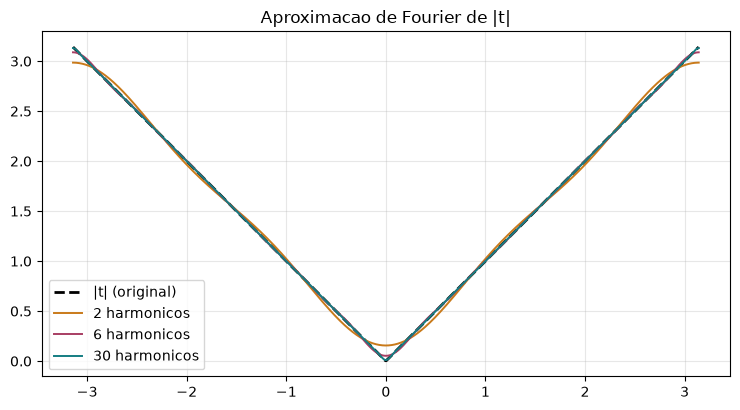


OK - algebra linear, EDOs e Fourier com NumPy/SymPy.


In [2]:

%matplotlib inline
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import odeint

print("=" * 60)
print("1) SISTEMA LINEAR: 2x + y = 5 ; x - 3y = -1")
A = np.array([[2, 1], [1, -3]])
b = np.array([5, -1])
x = np.linalg.solve(A, b)
print("   x =", x[0].round(4), " y =", x[1].round(4))

print("\n2) AUTOVALORES/AUTOVETORES de [[4, 1], [2, 3]]")
w, v = np.linalg.eig(np.array([[4, 1], [2, 3]]))
print("   autovalores:", w.round(4))
print("   autovetores (colunas):\n", v.round(4))

print("\n3) ROTACAO DE 45 GRAUS no vetor [1, 0]")
th = np.radians(45)
R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
print("   R(45) =\n", R.round(4))
print("   R * [1,0] =", (R @ np.array([1., 0.])).round(4))

print("\n4) EDO: y'' + y = 0, y(0)=1, y'(0)=0  ->  y = cos(t)")
t = sp.symbols("t")
y = sp.Function("y")
edo = sp.Eq(sp.diff(y(t), t, 2) + y(t), 0)
sol = sp.dsolve(edo, y(t), ics={y(0): 1, sp.diff(y(t), t).subs(t, 0): 0})
print("   solucao:", sol)

print("\n5) SERIE DE FOURIER de f(t) = |t| em [-pi, pi]")
def fourier(tv, N=10):
    out = np.pi/2
    for k in range(1, N + 1):
        out += (-4/np.pi) * np.cos((2*k - 1)*tv)/(2*k - 1)**2
    return out
tt = np.linspace(-np.pi, np.pi, 800)
plt.figure(figsize=(7.5, 4.2))
plt.plot(tt, np.abs(tt), "k--", lw=2, label="|t| (original)")
for N, col in ((2, "#C97A1A"), (6, "#A83E63"), (30, "#147D82")):
    plt.plot(tt, fourier(tt, N), lw=1.4, color=col, label=f"{N} harmonicos")
plt.title("Aproximacao de Fourier de |t|")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("\nOK - algebra linear, EDOs e Fourier com NumPy/SymPy.")


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
